In [2]:
import numpy as np
import matplotlib.pyplot as pp
import pandas as pd
import seaborn

In [3]:
%matplotlib inline

In [4]:
import zipfile
zipfile.ZipFile('names.zip').extractall('.')

In [5]:
import os
os.listdir('names')

['NationalReadMe.pdf',
 'yob1880.txt',
 'yob1881.txt',
 'yob1882.txt',
 'yob1883.txt',
 'yob1884.txt',
 'yob1885.txt',
 'yob1886.txt',
 'yob1887.txt',
 'yob1888.txt',
 'yob1889.txt',
 'yob1890.txt',
 'yob1891.txt',
 'yob1892.txt',
 'yob1893.txt',
 'yob1894.txt',
 'yob1895.txt',
 'yob1896.txt',
 'yob1897.txt',
 'yob1898.txt',
 'yob1899.txt',
 'yob1900.txt',
 'yob1901.txt',
 'yob1902.txt',
 'yob1903.txt',
 'yob1904.txt',
 'yob1905.txt',
 'yob1906.txt',
 'yob1907.txt',
 'yob1908.txt',
 'yob1909.txt',
 'yob1910.txt',
 'yob1911.txt',
 'yob1912.txt',
 'yob1913.txt',
 'yob1914.txt',
 'yob1915.txt',
 'yob1916.txt',
 'yob1917.txt',
 'yob1918.txt',
 'yob1919.txt',
 'yob1920.txt',
 'yob1921.txt',
 'yob1922.txt',
 'yob1923.txt',
 'yob1924.txt',
 'yob1925.txt',
 'yob1926.txt',
 'yob1927.txt',
 'yob1928.txt',
 'yob1929.txt',
 'yob1930.txt',
 'yob1931.txt',
 'yob1932.txt',
 'yob1933.txt',
 'yob1934.txt',
 'yob1935.txt',
 'yob1936.txt',
 'yob1937.txt',
 'yob1938.txt',
 'yob1939.txt',
 'yob1940.txt',
 

In [6]:
open('names/yob2011.txt','r').readlines()[:10]

['Sophia,F,21816\n',
 'Isabella,F,19870\n',
 'Emma,F,18777\n',
 'Olivia,F,17294\n',
 'Ava,F,15480\n',
 'Emily,F,14236\n',
 'Abigail,F,13229\n',
 'Madison,F,12360\n',
 'Mia,F,11512\n',
 'Chloe,F,10970\n']

In [7]:
names2011 = pd.read_csv('names/yob2011.txt')

In [8]:
names2011.head()

,Sophia,F,21816
0,Isabella,F,19870
1,Emma,F,18777
2,Olivia,F,17294
3,Ava,F,15480
4,Emily,F,14236


In [9]:
names2011 = pd.read_csv('names/yob2011.txt',names=['name','sex','number'])

In [10]:
names2011.head()

,name,sex,number
0,Sophia,F,21816
1,Isabella,F,19870
2,Emma,F,18777
3,Olivia,F,17294
4,Ava,F,15480


In [11]:
names_all = []

for year in range(1880,2014+1):
    names_all.append(pd.read_csv('names/yob{}.txt'.format(year),names=['name','sex','number']))
    names_all[-1]['year'] = year

allyears = pd.concat(names_all)

In [12]:
allyears.head()

,name,sex,number,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880


In [13]:
allyears.tail()

,name,sex,number,year
33039,Zykeem,M,5,2014
33040,Zymeer,M,5,2014
33041,Zymiere,M,5,2014
33042,Zyran,M,5,2014
33043,Zyrin,M,5,2014


In [14]:
allyears_indexed = allyears.set_index(['sex','name','year']).sort_index()

In [15]:
allyears_indexed

number
sex name      year        
F   Aabha     2011       7
              2012       5
              2014       9
    Aabriella 2008       5
              2014       5
...                    ...
M   Zytavious 2009       7
              2010       6
    Zyvion    2009       5
    Zyyon     2014       6
    Zzyzx     2010       5

[1825433 rows x 1 columns]

In [16]:
allyears_indexed.loc['F','Mary']

,number
year,
1880,7065
1881,6919
1882,8148
1883,8012
1884,9217
...,...
2010,2862
2011,2701
2012,2565


In [17]:
def plotname(sex,name):
    data = allyears_indexed.loc[sex,name]
    
    pp.plot(data.index,data.values)

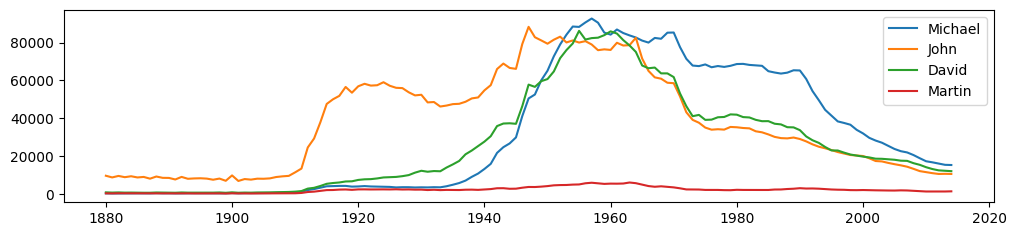

In [18]:
pp.figure(figsize=(12,2.5))

names = ['Michael','John','David','Martin']

for name in names:
    plotname('M',name)

pp.legend(names)

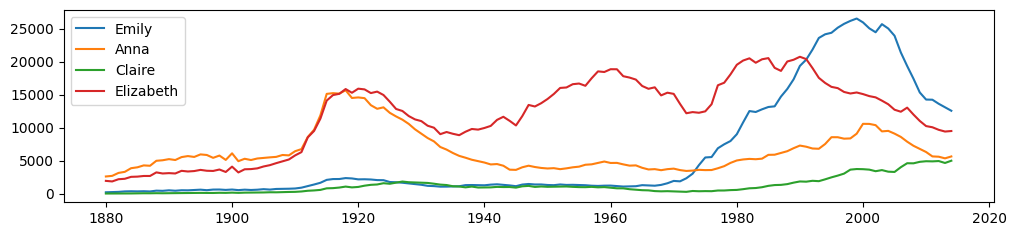

In [19]:
pp.figure(figsize=(12,2.5))

names = ['Emily','Anna','Claire','Elizabeth']

for name in names:
    plotname('F',name)

pp.legend(names)

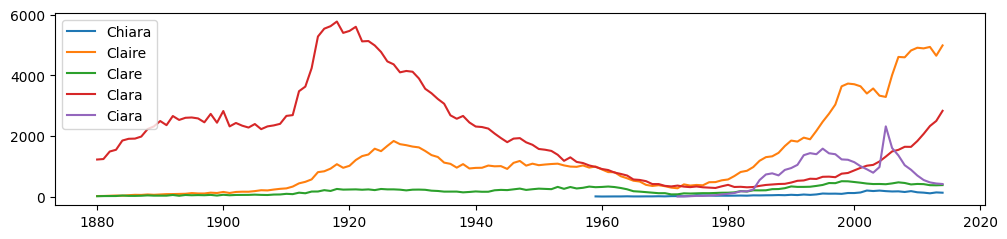

In [20]:
pp.figure(figsize=(12,2.5))

names = ['Chiara','Claire','Clare','Clara','Ciara']

for name in names:
    plotname('F',name)

pp.legend(names)

In [21]:
allyears_indexed.loc['F'].loc[names].head()

number
name   year        
Chiara 1959       9
       1960       5
       1962       8
       1963       8
       1964      12

In [22]:
allyears_indexed.loc['F'].loc[names].unstack(level=0).head()

number                           
name Chiara Claire Clare   Clara Ciara
year                                  
1880    NaN   21.0  15.0  1226.0   NaN
1881    NaN   23.0  20.0  1242.0   NaN
1882    NaN   30.0  21.0  1490.0   NaN
1883    NaN   38.0  22.0  1548.0   NaN
1884    NaN   33.0  38.0  1852.0   NaN

In [23]:
allyears_indexed.loc['F'].loc[names].unstack(level=0).fillna(0).head()

number                           
name Chiara Claire Clare   Clara Ciara
year                                  
1880    0.0   21.0  15.0  1226.0   0.0
1881    0.0   23.0  20.0  1242.0   0.0
1882    0.0   30.0  21.0  1490.0   0.0
1883    0.0   38.0  22.0  1548.0   0.0
1884    0.0   33.0  38.0  1852.0   0.0

In [29]:
variants = allyears_indexed.loc['F'].loc[names].unstack(level=0).fillna(0)['number']

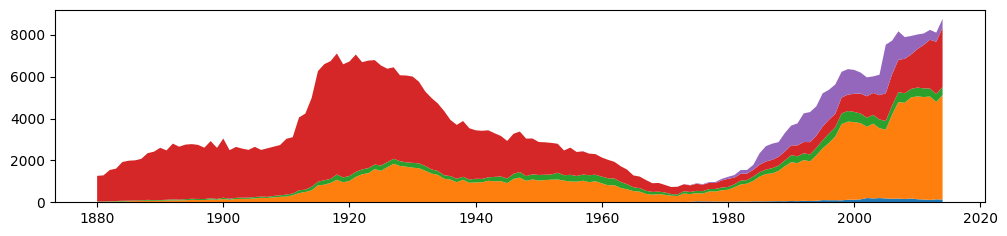

In [37]:
pp.figure(figsize=(12,2.5))

pp.stackplot(variants.index,variants.values.T,labels=names)

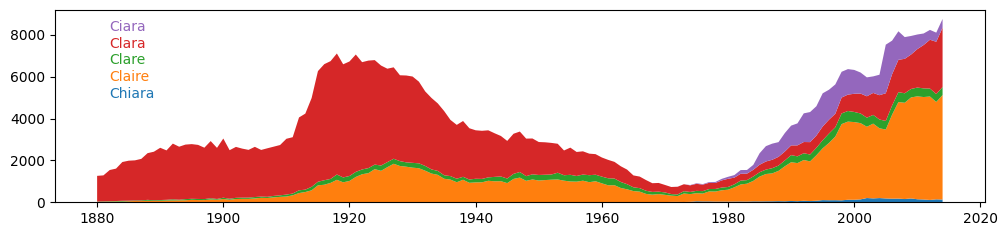

In [38]:
pp.figure(figsize=(12,2.5))

palette = seaborn.color_palette()
pp.stackplot(variants.index,variants.values.T,colors=palette)

for i,name in enumerate(names):
    pp.text(1882,5000 + 800*i,name,color=palette[i])

In [52]:
allyears_indexed.loc['M',:,2010].sort_values('number',ascending=False).head()

,number
name,
Jacob,22082
Ethan,17985
Michael,17308
Jayden,17152
William,17030


In [55]:
pop2010 = allyears_indexed.loc['M',:,2010].sort_values('number',ascending=False).head()
pop2010

,number
name,
Jacob,22082
Ethan,17985
Michael,17308
Jayden,17152
William,17030


In [72]:
def top10(sex, year):
    sample = allyears_indexed.loc[sex,:,year].sort_values('number',ascending=False).reset_index()
    sample = sample.drop(['number'], axis=1).head(10)

    sample.columns = [year]
    sample.index = sample.index + 1

    return(sample)

In [73]:
top10('F', 2010)

,2010
1,Isabella
2,Sophia
3,Emma
4,Olivia
5,Ava
6,Emily
7,Abigail
8,Madison
9,Chloe
10,Mia


In [76]:
def toptens(sex,year0,year1):
    years = [top10(sex,year) for year in range(year0, year1+1)]

    return(years[0].join(years[1:]))

In [77]:
toptens('F',2000, 2010)

,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010
1,Emily,Emily,Emily,Emily,Emily,Emily,Emily,Emily,Emma,Isabella,Isabella
2,Hannah,Madison,Madison,Emma,Emma,Emma,Emma,Isabella,Isabella,Emma,Sophia
3,Madison,Hannah,Hannah,Madison,Madison,Madison,Madison,Emma,Emily,Olivia,Emma
4,Ashley,Ashley,Emma,Hannah,Olivia,Abigail,Isabella,Ava,Olivia,Sophia,Olivia
5,Sarah,Alexis,Alexis,Olivia,Hannah,Olivia,Ava,Madison,Ava,Ava,Ava
6,Alexis,Sarah,Ashley,Abigail,Abigail,Isabella,Abigail,Sophia,Madison,Emily,Emily
7,Samantha,Samantha,Abigail,Alexis,Isabella,Hannah,Olivia,Olivia,Sophia,Madison,Abigail
8,Jessica,Abigail,Sarah,Ashley,Ashley,Samantha,Hannah,Abigail,Abigail,Abigail,Madison
9,Elizabeth,Elizabeth,Samantha,Elizabeth,Samantha,Ava,Sophia,Hannah,Elizabeth,Chloe,Chloe
10,Taylor,Olivia,Olivia,Samantha,Elizabeth,Ashley,Samantha,Elizabeth,Chloe,Mia,Mia


In [78]:
# get 6 most popular names in this dicade 

toptens('F',2000, 2010).stack().head()



1  2000    Emily
   2001    Emily
   2002    Emily
   2003    Emily
   2004    Emily
dtype: object

In [80]:
# this will count how many times does the name appear in the top 10 (i.e. in the toptens('F',2000, 2010) table)
toptens('F', 2000, 2010).stack().value_counts()

Emily        11
Madison      11
Olivia       10
Abigail      10
Emma          9
Hannah        8
Isabella      7
Samantha      7
Elizabeth     6
Ava           6
Ashley        6
Sophia        5
Alexis        4
Sarah         3
Chloe         3
Mia           2
Jessica       1
Taylor        1
Name: count, dtype: int64

In [83]:
# pick the most popular names (names only)
popular = toptens('F',2000,2010).stack().value_counts().index[:6]
popular

Index(['Emily', 'Madison', 'Olivia', 'Abigail', 'Emma', 'Hannah'], dtype='object')

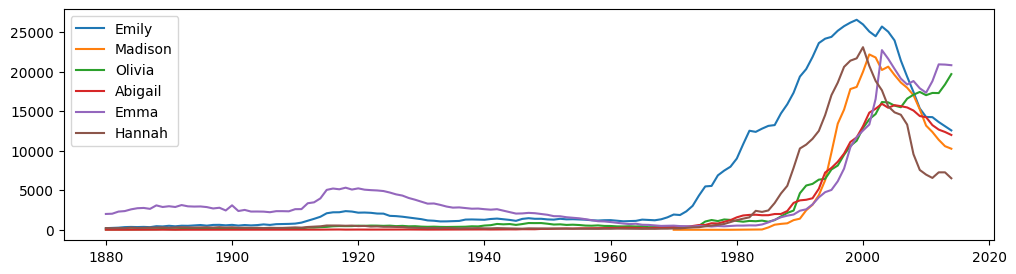

In [86]:
pp.figure(figsize=(12,3))

for name in popular:
    plotname('F', name)

pp.legend(popular)